# Black–Litterman

The estimators so far take the data at face value. But you often *have a view* — "Apple will
return 8 bps a day", "Microsoft will beat AMD", "tech as a group will do well" — and want to
fold that conviction into the prior without throwing away what the market already tells you.
That is exactly what the **Black–Litterman** model does: it starts from a neutral
*equilibrium* prior (the returns implied by holding the market), then tilts it toward your
views, weighting each by its confidence. The result is a posterior mean and covariance you can
feed to any optimiser.

This is the first of a short, sequenced arc on **view-based priors** — Black–Litterman here,
then [Entropy Pooling](07_Entropy_Pooling.md), then [Opinion Pooling](08_Opinion_Pooling.md).
Each builds on the last, but each page also stands alone.

In `PortfolioOptimisers`, `BlackLittermanPrior` takes a base estimator `pe` (whose
default mean is `EquilibriumExpectedReturns`), an `AssetSets` that names assets
and groups, and a `views` estimator. Views are written as plain string constraints through a
`LinearConstraintEstimator`, and their conviction is controlled by `views_conf` and the
global scaling parameter `tau`.

> **When to reach for this**
>
> Reach for Black–Litterman when you hold subjective forecasts — absolute ("this asset will
> return x"), relative ("A will beat B"), or group-level ("tech beats energy") — and want a
> principled blend of those views with a market-equilibrium baseline rather than overwriting
> the mean wholesale. It is the gentlest of the view priors: views enter as a Gaussian update
> on the mean. If your views are about quantities other than the mean (variance, tail risk,
> skew), or you want them as hard distributional constraints, see Entropy Pooling.

In [1]:
using PortfolioOptimisers, PrettyTables

mmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=4)) %" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. The equilibrium prior

Black–Litterman does not start from the sample mean. Its baseline is the
`EquilibriumExpectedReturns` vector — the returns *implied* by the market via reverse
optimisation ($\\boldsymbol{\\pi} = \\lambda \\mathbf{\\Sigma} \\boldsymbol{w}_{mkt}$). This
matters because the raw sample mean over a single year is noisy and often negative, whereas the
equilibrium prior is a smoother, economically-motivated anchor that the views then nudge.

We build both and compare them.

In [3]:
pr_sample = prior(EmpiricalPrior(), rd)
pr_eq = prior(EmpiricalPrior(; me = EquilibriumExpectedReturns()), rd)

pretty_table(DataFrame(["Assets" => rd.nx, "Sample mean" => pr_sample.mu,
                        "Equilibrium" => pr_eq.mu]); formatters = [mmtfmt],
             title = "Sample mean vs equilibrium prior")

   Sample mean vs equilibrium prior
┌────────┬─────────────┬─────────────┐
│ Assets │ Sample mean │ Equilibrium │
│ String │     Float64 │     Float64 │
├────────┼─────────────┼─────────────┤
│   AAPL │   -0.1126 % │    0.0231 % │
│    AMD │   -0.2809 % │    0.0362 % │
│    BAC │   -0.0934 % │    0.0191 % │
│    BBY │   -0.0279 % │    0.0239 % │
│    CVX │    0.1945 % │    0.0144 % │
│     GE │   -0.0339 % │    0.0194 % │
│     HD │   -0.0707 % │    0.0178 % │
│    JNJ │    0.0307 % │    0.0075 % │
│    JPM │   -0.0417 % │    0.0176 % │
│     KO │    0.0497 % │    0.0108 % │
│    LLY │    0.1305 % │    0.0122 % │
│    MRK │    0.1669 % │    0.0075 % │
│   MSFT │   -0.1206 % │     0.022 % │
│    PEP │     0.039 % │    0.0106 % │
│      ⋮ │           ⋮ │           ⋮ │
└────────┴─────────────┴─────────────┘
                        6 rows omitted


Noisy sample-mean expected returns.

In [4]:
using StatsPlots, GraphRecipes

Smoother market-equilibrium prior.

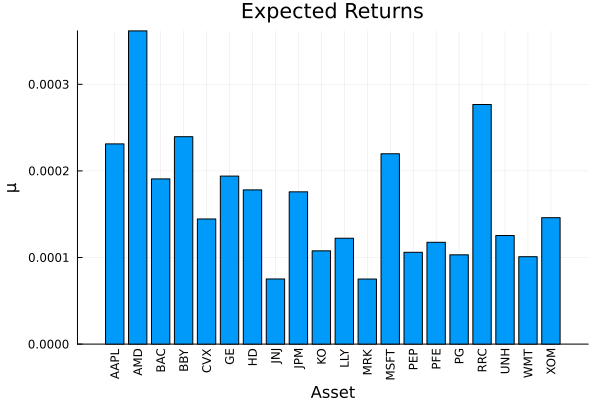

In [5]:
plot_mu(pr_sample, rd.nx)
plot_mu(pr_eq, rd.nx)

## 3. Naming assets and groups

Views refer to assets and groups by name, so we declare an `AssetSets`: the `nx` key
holds every asset, and we add two illustrative groups so we can express a group-level view.

In [6]:
sets = AssetSets(;
                 dict = Dict("nx" => rd.nx, "tech" => ["AAPL", "AMD", "MSFT"],
                             "energy" => ["CVX"]))

AssetSets
   key ┼ String: "nx"
  ukey ┼ String: "ux"
  dict ┴ Dict{String, Vector{String}}: Dict("nx" => ["AAPL", "AMD", "BAC", "BBY", "CVX", "GE", "HD", "JNJ", "JPM", "KO", "LLY", "MRK", "MSFT", "PEP", "PFE", "PG", "RRC", "UNH", "WMT", "XOM"], "tech" => ["AAPL", "AMD", "MSFT"], "energy" => ["CVX"])


## 4. The three kinds of views

Views are plain strings, and Black–Litterman understands three shapes:

  - **Absolute** — `"AAPL == 0.0008"`: Apple returns 8 bps a day.
  - **Relative** — `"MSFT - AMD == 0.0005"`: Microsoft beats AMD by 5 bps.
  - **Group** — `"tech == 0.0006"`: the tech group averages 6 bps.

We build one posterior per view type and compare the resulting expected returns against the
equilibrium prior. A key property to notice: BL views are *soft*. The posterior does not
reproduce the view exactly — it Bayesian-blends the view with the equilibrium anchor, so the
realised tilt is partial (the relative gap below lands well short of the stated 5 bps).

In [7]:
tau = 1 / size(rd.X, 1)

pr_abs = prior(BlackLittermanPrior(; sets = sets, tau = tau,
                                   views = LinearConstraintEstimator(;
                                                                     val = ["AAPL == 0.0008"])),
               rd)
pr_rel = prior(BlackLittermanPrior(; sets = sets, tau = tau,
                                   views = LinearConstraintEstimator(;
                                                                     val = ["MSFT - AMD == 0.0005"])),
               rd)
pr_grp = prior(BlackLittermanPrior(; sets = sets, tau = tau,
                                   views = LinearConstraintEstimator(;
                                                                     val = ["tech == 0.0006"])),
               rd)

pretty_table(DataFrame(["Assets" => rd.nx, "Equilibrium" => pr_eq.mu,
                        "Absolute" => pr_abs.mu, "Relative" => pr_rel.mu,
                        "Group" => pr_grp.mu]); formatters = [mmtfmt],
             title = "Posterior expected returns by view type")

         Posterior expected returns by view type
┌────────┬─────────────┬──────────┬───────────┬──────────┐
│ Assets │ Equilibrium │ Absolute │  Relative │    Group │
│ String │     Float64 │  Float64 │   Float64 │  Float64 │
├────────┼─────────────┼──────────┼───────────┼──────────┤
│   AAPL │    0.0231 % │ 0.0516 % │  0.0135 % │ 0.0363 % │
│    AMD │    0.0362 % │ 0.0719 % │ -0.0013 % │ 0.0594 % │
│    BAC │    0.0191 % │ 0.0338 % │   0.011 % │ 0.0272 % │
│    BBY │    0.0239 % │ 0.0434 % │  0.0133 % │ 0.0345 % │
│    CVX │    0.0144 % │ 0.0222 % │  0.0089 % │ 0.0187 % │
│     GE │    0.0194 % │ 0.0348 % │  0.0082 % │ 0.0279 % │
│     HD │    0.0178 % │ 0.0327 % │  0.0124 % │ 0.0257 % │
│    JNJ │    0.0075 % │ 0.0126 % │  0.0074 % │ 0.0096 % │
│    JPM │    0.0176 % │ 0.0307 % │  0.0109 % │ 0.0247 % │
│     KO │    0.0108 % │  0.019 % │  0.0089 % │ 0.0145 % │
│    LLY │    0.0122 % │ 0.0202 % │  0.0106 % │ 0.0162 % │
│    MRK │    0.0075 % │  0.012 % │  0.0084 % │ 0.0092 % │
│   MSF

## 5. Controlling conviction with `views_conf`

How hard the posterior leans on a view is set by `views_conf` — a confidence in $[0, 1]$ per
view. At low confidence the posterior stays near the equilibrium prior; at high confidence it
moves most of the way to the view. We sweep the confidence on a single absolute view and watch
Apple's posterior expected return climb from the equilibrium baseline toward the 8 bps target.

In [8]:
abs_view = LinearConstraintEstimator(; val = ["AAPL == 0.0008"])
confs = [0.1, 0.3, 0.5, 0.7, 0.9]
pr_confs = [prior(BlackLittermanPrior(; sets = sets, tau = tau, views = abs_view,
                                      views_conf = [c]), rd) for c in confs]

i_aapl = findfirst(==("AAPL"), rd.nx)
pretty_table(DataFrame(; confidence = confs,
                       Symbol("AAPL posterior") => [p.mu[i_aapl] for p in pr_confs]);
             formatters = [mmtfmt],
             title = "AAPL posterior vs view confidence (equilibrium ≈ $(round(pr_eq.mu[i_aapl]*100; digits=4))%, view = 0.08%)")

AAPL posterior vs view confidence (equilibrium ≈ 0.0231%, view = 0.08%)
┌────────────┬────────────────┐
│ confidence │ AAPL posterior │
│    Float64 │        Float64 │
├────────────┼────────────────┤
│        0.1 │       0.0288 % │
│        0.3 │       0.0402 % │
│        0.5 │       0.0516 % │
│        0.7 │       0.0629 % │
│        0.9 │       0.0743 % │
└────────────┴────────────────┘


## 6. The posterior covariance

Black–Litterman updates the *covariance* too, not only the mean: the posterior reflects the
extra information the views carry. With a small `tau` the adjustment is modest, but it is there
— compare Apple's posterior variance against the empirical one.

In [9]:
pretty_table(DataFrame(["quantity" => ["AAPL variance"],
                        "Empirical" => [pr_sample.sigma[i_aapl, i_aapl]],
                        "BL posterior" => [pr_abs.sigma[i_aapl, i_aapl]]]);
             formatters = [mmtfmt], title = "Posterior covariance adjustment")

      Posterior covariance adjustment
┌───────────────┬───────────┬──────────────┐
│      quantity │ Empirical │ BL posterior │
│        String │   Float64 │      Float64 │
├───────────────┼───────────┼──────────────┤
│ AAPL variance │    0.05 % │     0.0501 % │
└───────────────┴───────────┴──────────────┘


## 7. From views to portfolios

Finally, the payoff: the views reshape the portfolio. We do this two ways. First a single
maximum-ratio portfolio under the equilibrium prior vs the Apple-bullish posterior, then a full
efficient frontier under each so the tilt is visible across the whole risk/return range.

In [10]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

res_eq = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                           opt = JuMPOptimiser(; pe = pr_eq, slv = slv)))
res_bl = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                           opt = JuMPOptimiser(; pe = pr_abs, slv = slv)))

pretty_table(DataFrame(["Assets" => rd.nx, "Equilibrium" => res_eq.w,
                        "Black-Litterman" => res_bl.w]); formatters = [resfmt],
             title = "Maximum-ratio weights: equilibrium vs Black–Litterman")

Maximum-ratio weights: equilibrium vs Black–Litterman
┌────────┬─────────────┬─────────────────┐
│ Assets │ Equilibrium │ Black-Litterman │
│ String │     Float64 │         Float64 │
├────────┼─────────────┼─────────────────┤
│   AAPL │       0.0 % │        70.119 % │
│    AMD │    78.713 % │        23.276 % │
│    BAC │       0.0 % │           0.0 % │
│    BBY │       0.0 % │         1.041 % │
│    CVX │       0.0 % │           0.0 % │
│     GE │       0.0 % │           0.0 % │
│     HD │       0.0 % │           0.0 % │
│    JNJ │       0.0 % │           0.0 % │
│    JPM │       0.0 % │           0.0 % │
│     KO │       0.0 % │           0.0 % │
│    LLY │       0.0 % │           0.0 % │
│    MRK │       0.0 % │           0.0 % │
│   MSFT │       0.0 % │           0.0 % │
│    PEP │       0.0 % │           0.0 % │
│      ⋮ │           ⋮ │               ⋮ │
└────────┴─────────────┴─────────────────┘
                            6 rows omitted


The composition plot makes the maximum-ratio tilt visible.

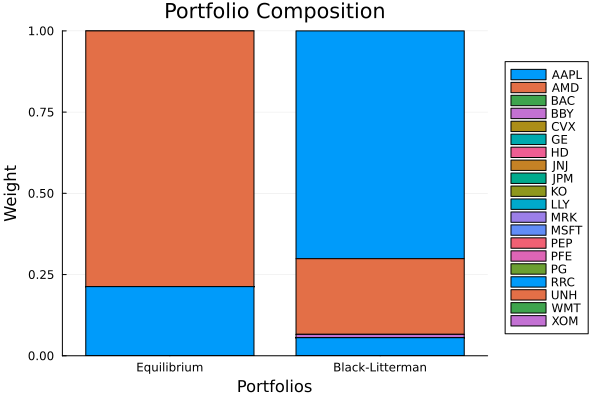

In [11]:
plot_stacked_bar_composition([res_eq, res_bl], rd;
                             xticks = (1:2, ["Equilibrium", "Black-Litterman"]))

And the efficient frontiers: minimum-risk portfolios across a sweep of return targets, under
the equilibrium prior and the Black–Litterman posterior. The view shifts the whole frontier.

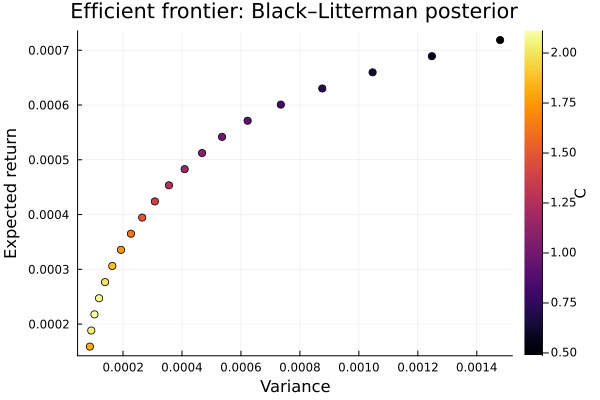

In [12]:
fr_eq = optimise(MeanRisk(; obj = MinimumRisk(),
                          opt = JuMPOptimiser(; pe = pr_eq, slv = slv,
                                              ret = ArithmeticReturn(;
                                                                     lb = Frontier(;
                                                                                   N = 20)))))
fr_bl = optimise(MeanRisk(; obj = MinimumRisk(),
                          opt = JuMPOptimiser(; pe = pr_abs, slv = slv,
                                              ret = ArithmeticReturn(;
                                                                     lb = Frontier(;
                                                                                   N = 20)))))

plot_measures(fr_eq.w, pr_eq; x = Variance(), y = ExpectedReturn(; rt = fr_eq.ret),
              title = "Efficient frontier: equilibrium prior", xlabel = "Variance",
              ylabel = "Expected return")

plot_measures(fr_bl.w, pr_abs; x = Variance(), y = ExpectedReturn(; rt = fr_bl.ret),
              title = "Efficient frontier: Black–Litterman posterior", xlabel = "Variance",
              ylabel = "Expected return")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*